# Extract Frames from Train / Val / Test

In [1]:
import cv2
import os
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/extracted_frames.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/extracted_frames/train/mask/0192_f0012.png  
  inflating: /content/extracted_frames/train/mask/0192_f0013.png  
  inflating: /content/extracted_frames/train/mask/0192_f0014.png  
  inflating: /content/extracted_frames/train/mask/0192_f0015.png  
  inflating: /content/extracted_frames/train/mask/0193_f0000.png  
  inflating: /content/extracted_frames/train/mask/0193_f0001.png  
  inflating: /content/extracted_frames/train/mask/0193_f0002.png  
  inflating: /content/extracted_frames/train/mask/0193_f0003.png  
  inflating: /content/extracted_frames/train/mask/0193_f0004.png  
  inflating: /content/extracted_frames/train/mask/0193_f0005.png  
  inflating: /content/extracted_frames/train/mask/0193_f0006.png  
  inflating: /content/extracted_frames/train/mask/0193_f0007.png  
  inflating: /content/extracted_frames/train/mask/0193_f0008.png  
  inflating: /content/extracted_frames/train/mask/0193_f0009.png  
  inflating

In [4]:
DATASET_ROOT = "/content/pothole_dataset/pothole_video"
OUTPUT_ROOT = "/content/extracted_frames"



In [5]:
FRAME_SKIP = 3

In [6]:
def extract_split(split_name):
    print(f"Extracting frames from {split_name} folder")
    rgb_folder=os.path.join(DATASET_ROOT,split_name,"rgb")
    mask_folder=os.path.join(DATASET_ROOT,split_name,"mask")
    out_rgb_folder=os.path.join(OUTPUT_ROOT,split_name,"rgb")
    out_mask_folder=os.path.join(OUTPUT_ROOT,split_name,"mask")
    os.makedirs(out_rgb_folder,exist_ok=True)
    os.makedirs(out_mask_folder,exist_ok=True)
    rgb_videos=sorted(os.listdir(rgb_folder))
    print(f"{len(rgb_videos)} videos in {split_name} folder")
    for video_file in rgb_videos:
        rgb_path=os.path.join(rgb_folder,video_file)
        mask_path=os.path.join(mask_folder,video_file)
        if not os.path.exists(mask_path):
            print(f"Mask video missing for {video_file}")
            continue
        cap_rgb=cv2.VideoCapture(rgb_path)
        cap_mask=cv2.VideoCapture(mask_path)
        frame_id=0
        saved_id=0
        video_id=Path(video_file).stem
        while True:
            ret1,frame_rgb=cap_rgb.read()
            ret2,frame_mask=cap_mask.read()
            if not ret1 or not ret2:
                break
            if frame_id%FRAME_SKIP==0:
                filename=f"{video_id}_f{saved_id:04d}.png"
                cv2.imwrite(os.path.join(out_rgb_folder,filename),frame_rgb)
                cv2.imwrite(os.path.join(out_mask_folder,filename),frame_mask)
                saved_id+=1
            frame_id+=1
        cap_rgb.release()
        cap_mask.release()
        print(f"Extracted {saved_id} frames from {video_file}")

    print(f"Done extracting {split_name} folder")

# extract_split("train")
# extract_split("val")
# extract_split("test")

# Alignment Check

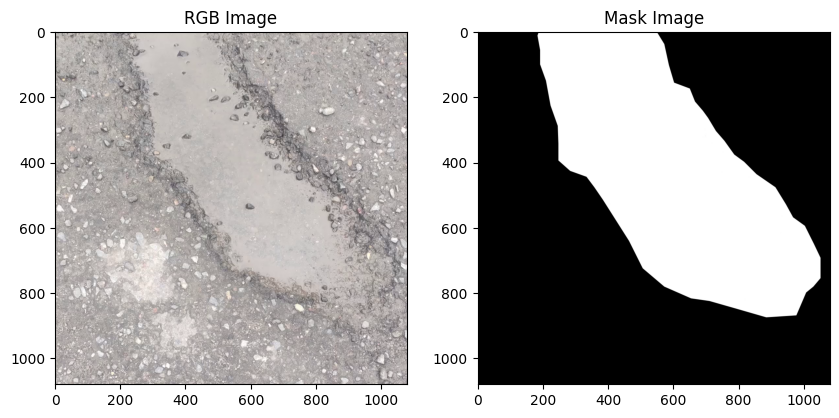

In [7]:
import matplotlib.pyplot as plt
img_path=OUTPUT_ROOT + "/train/rgb/0010_f0000.png"
mask_path=OUTPUT_ROOT + "/train/mask/0010_f0000.png"
img=cv2.imread(img_path)
mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("RGB Image")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.title("Mask Image")
plt.imshow(mask,cmap="gray")
plt.show()

# Preprocessing

In [8]:
import torch
from torch.utils.data import Dataset

In [9]:
import random
import torchvision.transforms.functional as TF

In [10]:
class PotHoleDataset(Dataset):
    def __init__(self,rgb_dir,mask_dir,img_size=256,train=False):
        self.train = train
        self.rgb_dir=rgb_dir
        self.mask_dir=mask_dir
        self.img_size=img_size

        self.rgb_images=sorted(os.listdir(rgb_dir))

    def __len__(self):
        return len(self.rgb_images)

    def __getitem__(self,idx):
        img_name=self.rgb_images[idx]
        img_path=os.path.join(self.rgb_dir,img_name)
        mask_path=os.path.join(self.mask_dir,img_name)

        image=cv2.imread(img_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        image=cv2.resize(image,(self.img_size,self.img_size))
        image=image/255.0
        image=torch.tensor(image,dtype=torch.float32).permute(2,0,1)
        mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
        mask=cv2.resize(mask,(self.img_size,self.img_size),interpolation=cv2.INTER_NEAREST)
        mask=(mask>0).astype("float32")
        mask=torch.tensor(mask).unsqueeze(0)
        if self.train:

          # Horizontal Flip
          if random.random() > 0.5:
              image = TF.hflip(image)
              mask = TF.hflip(mask)

          # Small Rotation
          angle = random.uniform(-10, 10)
          image = TF.rotate(image, angle)
          mask = TF.rotate(mask, angle)

          # Random Brightness
          brightness_factor = random.uniform(0.8, 1.2)
          image = TF.adjust_brightness(image, brightness_factor)

        return image,mask

In [11]:
train_dataset=PotHoleDataset(rgb_dir=r"extracted_frames/train/rgb",
    mask_dir=r"extracted_frames/train/mask",
    img_size=256,
    train=True
    )
val_dataset = PotHoleDataset(
    rgb_dir=r"extracted_frames/val/rgb",
    mask_dir=r"extracted_frames/val/mask",
    img_size=256,
    train=False
    )
test_dataset=PotHoleDataset(
    rgb_dir=r"extracted_frames/test/rgb",
    mask_dir=r"extracted_frames/test/mask",
    img_size=256,
    train=False
)

In [12]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)
val_loader=DataLoader(val_dataset,batch_size=2,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=2,shuffle=False)

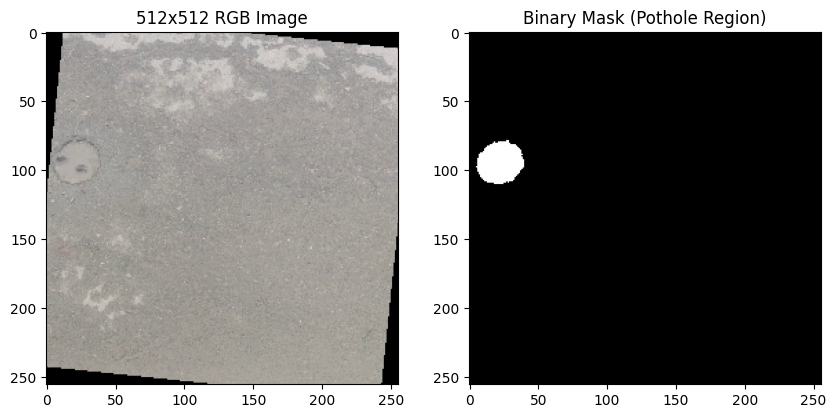

In [13]:
import matplotlib.pyplot as plt
image,mask=train_dataset[0]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("512x512 RGB Image")
plt.imshow(image.permute(1,2,0))
plt.subplot(1,2,2)
plt.title("Binary Mask (Pothole Region)")
plt.imshow(mask.squeeze(0),cmap="gray")
plt.show()

# IMPLEMENTATION (U-Net Model)

In [14]:
import torch
from torch import nn
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.block=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.block(x)

In [15]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32,64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64,128)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(128,256)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256,512)

        self.up4 = nn.ConvTranspose2d(512,256,2,2)
        self.conv4 = DoubleConv(512,256)

        self.up3 = nn.ConvTranspose2d(256,128,2,2)
        self.conv3 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.conv2 = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.conv1 = DoubleConv(64,32)

        self.out = nn.Conv2d(32,1,1)

    def forward(self,x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))

        b = self.bottleneck(self.pool4(d4))

        u4 = self.up4(b)
        u4 = torch.cat([u4,d4],dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3,d3],dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2,d2],dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1,d1],dim=1)
        u1 = self.conv1(u1)

        return torch.sigmoid(self.out(u1))

In [16]:
import torch.nn.functional as F
def dice_loss(pred,target,smooth=1e-6):
    pred=pred.view(-1)
    target=target.view(-1)
    intersection=(pred*target).sum()
    dice=(2*intersection+smooth)/(pred.sum()+target.sum()+smooth)
    return 1-dice
def combined_loss(pred,target):
    bce=F.binary_cross_entropy(pred,target)
    dice=dice_loss(pred,target)
    return bce+dice

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [18]:
model = UNet().to(device)

In [19]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-5
)

In [20]:
def dice_score(pred,target,smooth=1e-6):
    pred=(pred>0.5).float()
    intersection=(pred*target).sum()
    dice=(2*intersection+smooth)/(pred.sum()+target.sum()+smooth)
    return dice.item()

def iou_score(pred,target,smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

In [21]:
def train_one_epoch(model,loader,optimizer):
    model.train()
    total_loss=0
    total_dice=0
    total_iou=0
    for images,masks in loader:
        images=images.to(device)
        masks=masks.to(device)

        preds=model(images)

        loss=combined_loss(preds,masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        total_loss+=loss.item()
        total_dice+=dice_score(preds,masks)
        total_iou+=iou_score(preds,masks)
    n=len(loader)
    return total_loss/n,total_dice/n,total_iou/n


In [22]:
def validate_one_epoch(model,loader):
    model.eval()
    total_loss=0
    total_dice=0
    total_ioc=0
    with torch.inference_mode():
        for images,masks in loader:
            images=images.to(device)
            masks=masks.to(device)

            preds=model(images)

            loss=combined_loss(preds,masks)

            total_loss+=loss.item()
            total_dice+=dice_score(preds,masks)
            total_ioc+=iou_score(preds,masks)
    n=len(loader)
    return total_loss/n,total_dice/n,total_ioc/n

In [48]:
# num_epochs=15
# best_val_dice=0
# for epoch in range(num_epochs):
#     train_loss, train_dice, train_iou = train_one_epoch(
#         model, train_loader, optimizer
#     )

#     val_loss, val_dice, val_iou = validate_one_epoch(
#         model, val_loader
#     )

#     print(f"Epoch:{epoch+1}/{num_epochs}  |")
#     print(f"Train Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
#     print(f"Val   Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

#     if val_dice>best_val_dice:
#         best_val_dice=val_dice
#         torch.save(model.state_dict(),
#            "/content/drive/MyDrive/best_unet.pth")
#         print("Saved best model with Dice:", best_val_dice)



In [23]:
!unzip "/content/drive/MyDrive/test.zip" -d "/content/"

Archive:  /content/drive/MyDrive/test.zip
   creating: /content/test/
   creating: /content/test/mask/
  inflating: /content/test/mask/0465.mp4  
  inflating: /content/test/mask/0466.mp4  
  inflating: /content/test/mask/0467.mp4  
  inflating: /content/test/mask/0468.mp4  
  inflating: /content/test/mask/0469.mp4  
  inflating: /content/test/mask/0470.mp4  
  inflating: /content/test/mask/0471.mp4  
  inflating: /content/test/mask/0472.mp4  
  inflating: /content/test/mask/0473.mp4  
  inflating: /content/test/mask/0474.mp4  
  inflating: /content/test/mask/0475.mp4  
  inflating: /content/test/mask/0476.mp4  
  inflating: /content/test/mask/0477.mp4  
  inflating: /content/test/mask/0478.mp4  
  inflating: /content/test/mask/0479.mp4  
  inflating: /content/test/mask/0480.mp4  
  inflating: /content/test/mask/0561.mp4  
  inflating: /content/test/mask/0562.mp4  
  inflating: /content/test/mask/0563.mp4  
  inflating: /content/test/mask/0564.mp4  
  inflating: /content/test/mask/0565.

# Phase 6

In [24]:
model = UNet().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_unet.pth", map_location=device))
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [25]:
import numpy as np
def predict_frame(frame):
  h,w=frame.shape[:2]

  resized = cv2.resize(frame, (256,256))
  rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
  rgb = rgb / 255.0

  tensor = torch.tensor(rgb, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
  tensor = tensor.to(device)

  with torch.no_grad():
        output = model(tensor)
        mask = output.squeeze().cpu().numpy()

  mask = (mask > 0.5).astype(np.uint8)

  mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

  return mask

In [26]:
def run_single_video(input_path, output_path):

    cap = cv2.VideoCapture(input_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        mask = predict_frame(frame)

        overlay = frame.copy()
        overlay[mask == 1] = [0,0,255]

        alpha = 0.4
        output = cv2.addWeighted(frame, 1-alpha, overlay, alpha, 0)

        out.write(output)

        frame_count += 1
        if frame_count % 10 == 0:
            print("Processed frames:", frame_count)

    cap.release()
    out.release()

    print("Saved:", output_path)

In [ ]:
input_video = "/content/test/rgb/0465.mp4"
output_video = "/content/drive/MyDrive/output_baseline.mp4"

run_single_video(input_video, output_video)

Processed frames: 10
Processed frames: 20
Processed frames: 30
Processed frames: 40
Saved: /content/drive/MyDrive/output_baseline.mp4


In [ ]:
import os
video_folder = "/content/test/rgb"

for vid in os.listdir(video_folder):
    if vid.endswith(".mp4"):
        input_path = os.path.join(video_folder, vid)
        output_path = f"/content/drive/MyDrive/output_{vid}"

        print("Processing:", vid)
        run_single_video(input_path, output_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/rgb'

# PHASE 7 — Temporal Smoothing


In [27]:
N = 7

In [28]:
from collections import deque

def run_video_with_smoothing(input_path, output_path, N=5):

    cap = cv2.VideoCapture(input_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    prob_buffer = deque(maxlen=N)   # stores last N probability maps

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ---- Predict probability map (NOT thresholded) ----
        h, w = frame.shape[:2]

        resized = cv2.resize(frame, (256,256))
        rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        rgb = rgb / 255.0

        tensor = torch.tensor(rgb, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
        tensor = tensor.to(device)

        with torch.no_grad():
            output = model(tensor)
            prob_map = output.squeeze().cpu().numpy()

        # Store probability map
        prob_buffer.append(prob_map)

        # ---- Average last N probability maps ----
        smoothed_prob = np.mean(prob_buffer, axis=0)

        # Threshold
        mask = (smoothed_prob > 0.5).astype(np.uint8)

        # Resize back
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Overlay
        overlay = frame.copy()
        overlay[mask == 1] = [0,0,255]

        alpha = 0.4
        output_frame = cv2.addWeighted(frame, 1-alpha, overlay, alpha, 0)

        out.write(output_frame)

        frame_count += 1
        if frame_count % 10 == 0:
            print("Processed frames:", frame_count)

    cap.release()
    out.release()

    print("Saved smoothed video:", output_path)

In [ ]:
input_video = "/content/test/rgb/0465.mp4"
output_video = "/content/drive/MyDrive/output_smoothed.mp4"

run_video_with_smoothing(input_video, output_video, N=5)

Processed frames: 10
Processed frames: 20
Processed frames: 30
Processed frames: 40
Saved smoothed video: /content/drive/MyDrive/output_smoothed.mp4


# PHASE 8 — Persistence Logic

In [29]:
N = 5       # smoothing window
K = 3         # consecutive frame requirement
AREA_THRESH = 200   # minimum pothole area

In [30]:
from collections import deque

def run_video_with_persistence(input_path, mask_folder, output_path, N=5, K=3):
    cap = cv2.VideoCapture(input_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    prob_buffer = deque(maxlen=N)
    consecutive_count = 0
    area_list = []
    frame_counter = 0
    pred_masks = []
    gt_masks = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ---- Predict ----
        resized = cv2.resize(frame, (256,256))
        rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) / 255.0

        tensor = torch.tensor(rgb, dtype=torch.float32)\
                    .permute(2,0,1).unsqueeze(0).to(device)

        with torch.no_grad():
            prob_map = model(tensor).squeeze().cpu().numpy()

        prob_buffer.append(prob_map)

        # ---- Stable smoothing ----
        if len(prob_buffer) < N:
            smoothed_prob = prob_buffer[-1]
        else:
            smoothed_prob = np.mean(prob_buffer, axis=0)

        # Resize probability FIRST
        smoothed_prob = cv2.resize(smoothed_prob,
                                   (width, height),
                                   interpolation=cv2.INTER_LINEAR)

        mask = (smoothed_prob > 0.55).astype(np.uint8)

        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        # ---- Area check ----
        area = np.sum(mask)

        if area > AREA_THRESH:
            consecutive_count = min(consecutive_count + 1, K)
        else:
            consecutive_count = max(consecutive_count - 1, 0)

        if consecutive_count >= K:
            final_mask = mask
        else:
            final_mask = np.zeros_like(mask)


        area_pixels = np.sum(final_mask)
        area_list.append(area_pixels)
        frame_counter += 1

        # Overlay
        overlay = frame.copy()
        overlay[final_mask == 1] = [0,0,255]

        output_frame = cv2.addWeighted(frame, 0.6, overlay, 0.4, 0)

        out.write(output_frame)

        mask_filename = os.path.basename(input_path).replace(".mp4", f"_{frame_counter:04d}.png")
        gt_path = os.path.join(mask_folder, mask_filename)

        if os.path.exists(gt_path):
            gt_mask = cv2.imread(gt_path, 0)
            gt_mask = (gt_mask > 127).astype(np.uint8)
            gt_masks.append(gt_mask)
            pred_masks.append(final_mask)



    frame_area = width * height
    valid_ratios = [a/frame_area for a in area_list if a > 0]

    frames_with_pothole = len(valid_ratios)
    duration_seconds = frames_with_pothole / fps

    mean_ratio = np.mean(valid_ratios) if valid_ratios else 0
    max_ratio = np.max(valid_ratios) if valid_ratios else 0

    if mean_ratio < 0.03:
      everity = "Small"
    elif mean_ratio < 0.10:
        severity = "Medium"
    else:
        severity = "Large"

    print("\n---- Video Severity Report ----")
    print("Detected frames:", frames_with_pothole)
    print("Visible duration (s):", round(duration_seconds,2))
    print("Mean area ratio:", round(mean_ratio,4))
    print("Max area ratio:", round(max_ratio,4))
    print("Severity:", severity)
    cap.release()
    out.release()

    print("Saved persistence video:", output_path)



    dice_scores = []
    iou_scores = []

    for p, t in zip(pred_masks, gt_masks):
        dice, iou = compute_metrics(p, t)
        dice_scores.append(dice)
        iou_scores.append(iou)

    print("Persistence Video Evaluation")
    print("Mean Dice:", round(np.mean(dice_scores),4))
    print("Mean IoU:", round(np.mean(iou_scores),4))

In [31]:
mask_folder = "/content/extracted_frames/test/mask"

In [ ]:
input_video = "/content/test/rgb/0465.mp4"
output_video = "/content/drive/MyDrive/output_persistant.mp4"

run_video_with_persistence(input_video, mask_folder ,output_video, N=5, K=3)

ZeroDivisionError: float division by zero

# Phase 10

In [32]:
import numpy as np

def compute_metrics(pred_mask, true_mask):
    pred = pred_mask.flatten()
    true = true_mask.flatten()

    intersection = np.sum(pred * true)
    union = np.sum(pred) + np.sum(true)

    dice = (2 * intersection) / (union + 1e-8)
    iou = intersection / (np.sum(pred) + np.sum(true) - intersection + 1e-8)

    return dice, iou

In [33]:
def evaluate_raw_model(model, loader):

    model.eval()
    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = (outputs > 0.5).float()

            preds = preds.cpu().numpy()
            masks = masks.cpu().numpy()

            for p, t in zip(preds, masks):
                dice, iou = compute_metrics(p.squeeze(), t.squeeze())
                dice_scores.append(dice)
                iou_scores.append(iou)

    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)

    print("RAW Frame-wise Evaluation")
    print("Mean Dice:", round(mean_dice,4))
    print("Mean IoU:", round(mean_iou,4))

    return mean_dice, mean_iou

In [34]:
raw_dice, raw_iou = evaluate_raw_model(model, test_loader)

RAW Frame-wise Evaluation
Mean Dice: 0.6491
Mean IoU: 0.5353


In [36]:
def evaluate_single_video_persistence(
        input_video,
        mask_folder,
        model,
        device,
        AREA_THRESH,
        N=5,
        K=3,
        threshold=0.55):

    cap = cv2.VideoCapture(input_video)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    prob_buffer = deque(maxlen=N)
    consecutive_count = 0

    dice_scores = []
    iou_scores = []

    mask_files = sorted(os.listdir(mask_folder))
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret or frame_idx >= len(mask_files):
            break

        # ---- Model prediction ----
        resized = cv2.resize(frame, (256,256))
        rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) / 255.0

        tensor = torch.tensor(rgb, dtype=torch.float32)\
                    .permute(2,0,1).unsqueeze(0).to(device)

        with torch.no_grad():
            prob_map = model(tensor).squeeze().cpu().numpy()

        prob_buffer.append(prob_map)

        if len(prob_buffer) < N:
            smoothed_prob = prob_buffer[-1]
        else:
            smoothed_prob = np.mean(prob_buffer, axis=0)

        smoothed_prob = cv2.resize(smoothed_prob,
                                   (width, height),
                                   interpolation=cv2.INTER_LINEAR)

        mask = (smoothed_prob > threshold).astype(np.uint8)

        kernel = np.ones((3,3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # ---- Persistence ----
        area = np.sum(mask)

        if area > AREA_THRESH:
            consecutive_count = min(consecutive_count + 1, K)
        else:
            consecutive_count = max(consecutive_count - 1, 0)

        if consecutive_count >= K:
            final_mask = mask
        else:
            final_mask = np.zeros_like(mask)

        # ---- Load GT ----
        gt_path = os.path.join(mask_folder, mask_files[frame_idx])
        gt_mask = cv2.imread(gt_path, 0)
        gt_mask = (gt_mask > 127).astype(np.uint8)

        dice, iou = compute_metrics(final_mask, gt_mask)

        dice_scores.append(dice)
        iou_scores.append(iou)

        frame_idx += 1

    cap.release()

    return np.mean(dice_scores), np.mean(iou_scores)

In [46]:
def evaluate_test_frames_persistence(
        rgb_folder,
        mask_folder,
        model,
        device,
        AREA_THRESH,
        N=5,
        K=3,
        threshold=0.55):

    rgb_files = sorted(os.listdir(rgb_folder))
    mask_files = sorted(os.listdir(mask_folder))

    prob_buffer = deque(maxlen=N)
    consecutive_count = 0

    all_dice = []
    all_iou = []

    for rgb_file, mask_file in zip(rgb_files, mask_files):

        rgb_path = os.path.join(rgb_folder, rgb_file)
        mask_path = os.path.join(mask_folder, mask_file)

        frame = cv2.imread(rgb_path)
        gt_mask = cv2.imread(mask_path, 0)
        gt_mask = (gt_mask > 127).astype(np.uint8)

        height, width = frame.shape[:2]

        resized = cv2.resize(frame, (256,256))
        rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) / 255.0

        tensor = torch.tensor(rgb, dtype=torch.float32)\
                    .permute(2,0,1).unsqueeze(0).to(device)

        with torch.no_grad():
            prob_map = model(tensor).squeeze().cpu().numpy()

        prob_buffer.append(prob_map)

        if len(prob_buffer) < N:
            smoothed_prob = prob_buffer[-1]
        else:
            smoothed_prob = np.mean(prob_buffer, axis=0)

        smoothed_prob = cv2.resize(smoothed_prob,
                                   (width, height),
                                   interpolation=cv2.INTER_LINEAR)

        mask = (smoothed_prob > threshold).astype(np.uint8)

        kernel = np.ones((3,3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        area = np.sum(mask)

        if area > AREA_THRESH:
            consecutive_count = min(consecutive_count + 1, K)
        else:
            consecutive_count = max(consecutive_count - 1, 0)

        if consecutive_count >= K:
            final_mask = mask
        else:
            final_mask = np.zeros_like(mask)

        dice, iou = compute_metrics(final_mask, gt_mask)

        all_dice.append(dice)
        all_iou.append(iou)

    print("\n===== FINAL PERSISTENCE RESULTS =====")
    print("Mean Dice (Test Dataset):", round(np.mean(all_dice),4))
    print("Mean IoU  (Test Dataset):", round(np.mean(all_iou),4))

    return np.mean(all_dice), np.mean(all_iou)

In [47]:
rgb_folder = "/content/extracted_frames/test/rgb"
mask_folder = "/content/extracted_frames/test/mask"

pers_dice, pers_iou = evaluate_test_frames_persistence(
    rgb_folder,
    mask_folder,
    model,
    device,
    AREA_THRESH,
    N=5,
    K=3
)


===== FINAL PERSISTENCE RESULTS =====
Mean Dice (Test Dataset): 0.5103
Mean IoU  (Test Dataset): 0.3874
